# Week 6: Language Models
AI for Good - Minor ADSAI

[Open this notebook in Google Colab](https://colab.research.google.com/github/BTuyn/AI4G/blob/main/Week%206/Week6_Workshop_Student.ipynb) - nothing to install, everything
runs in your browser. If you opened it in Colab already: great.

Today you meet the three ideas behind every modern language model, one at a
time, each one fixing a problem of the one before:

| Step | Model | What it adds |
|------|-------|--------------|
| 1 | **Word embeddings** | words become numbers that carry meaning |
| 2 | **RNN**, then **LSTM** | reading in order, and remembering what you read |
| 3 | **Transformer** | looking at every word at once, so context decides the meaning |

You do **not** build or train any of these today. You use ready-made models
and look at what they do well, where they break, and who gets hurt when they
break. The spine of the week is the same as in Weeks 4 and 5:
**text -> numbers -> model -> prediction**.

Today runs in **three learning waves**, each starting with a short
mini-lecture. A wave starts at every horizontal line in this notebook,
marked like this:

**LEARNING WAVE 1 · SLIDES 4-8**

- Wave 1 - section 1: words as numbers (embeddings)
- Wave 2 - section 2: order and memory (RNN and LSTM)
- Wave 3 - section 3: context and attention (transformers)
- Then section 4: the big individual assignment, and section 5: wrap-up

Do not run ahead into the next wave - wait for the mini-lecture.

### 0. Setup - run these two cells once

Nothing to write here. Run each cell with Shift + Enter and wait until it
finishes (the first one downloads a 66 MB file, a few seconds). If a cell
prints a long warning about a missing token or about "unauthenticated
requests", ignore it.

In [1]:
# Run, do not read: downloads the pre-trained word embeddings (GloVe, trained by Stanford)
import urllib.request, gzip
import numpy as np
import matplotlib.pyplot as plt

url = "https://github.com/RaRe-Technologies/gensim-data/releases/download/glove-wiki-gigaword-50/glove-wiki-gigaword-50.gz"
urllib.request.urlretrieve(url, "glove50.gz")

words = []
vectors = []
with gzip.open("glove50.gz", "rt", encoding="utf-8") as f:
    f.readline()                       # first line is just file info
    for i, line in enumerate(f):
        if i >= 50000:                 # keep the 50,000 most common words
            break
        parts = line.rstrip().split(" ")
        words.append(parts[0])
        vectors.append(np.array(parts[1:], dtype="float32"))

V = np.vstack(vectors)
V = V / np.linalg.norm(V, axis=1, keepdims=True)   # length 1, so a dot product = similarity
index = {}
for i, w in enumerate(words):
    index[w] = i
print("Loaded", len(words), "words, each one a list of", V.shape[1], "numbers")

Loaded 50000 words, each one a list of 50 numbers


In [2]:
# Run, do not read: small helper functions that we use all day
def vector(word):
    return V[index[word]]

def similarity(a, b):
    # 1.0 = used in exactly the same way, 0 = nothing in common
    return round(float(vector(a) @ vector(b)), 2)

def neighbours(word, n=8):
    scores = V @ vector(word)
    best = np.argsort(-scores)[1:n + 1]
    return [(words[i], round(float(scores[i]), 2)) for i in best]

def analogy(a, b, c, n=5):
    # "a is to b as c is to ?"   (for example: man is to king as woman is to ?)
    target = vector(b) - vector(a) + vector(c)
    scores = V @ target
    result = []
    for i in np.argsort(-scores):
        if words[i] not in (a, b, c):
            result.append(words[i])
        if len(result) == n:
            break
    return result

def plot_words(word_list):
    # squash the 50 numbers per word into 2, so we can draw a map
    X = np.array([vector(w) for w in word_list])
    X = X - X.mean(axis=0)
    u, s, vt = np.linalg.svd(X, full_matrices=False)
    xy = X @ vt[:2].T
    plt.figure(figsize=(8, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for k, w in enumerate(word_list):
        plt.text(xy[k, 0] + 0.02, xy[k, 1] + 0.02, w, fontsize=11)
    plt.title("Words on a map (50 numbers squashed into 2)")
    plt.axis("off")
    plt.show()

---

**LEARNING WAVE 1 · SLIDES 4-8**

## 1. Words as numbers

Sections 1.1 to 1.7. From counting words to giving every word a position on a map of meaning.

### 1.1 What is an embedding?

In slide 5 a sentence became a row of word counts. A count tells you *which*
words appear, but not what they *mean*: to a count, `dog` and `cat` are as
unrelated as `dog` and `car`.

An **embedding** fixes that. Every word gets a list of numbers, and words
that are used in similar ways get similar numbers. The file you just loaded
was trained by Stanford on billions of words. It is **pre-trained**: you do
not train anything today.

Run the cell below. It shows the list of numbers for the word `clinic`.

In [3]:
print(vector("clinic")[:10])
print("This word is a list of", len(vector("clinic")), "numbers. We only printed the first 10.")

[ 0.21052876  0.05483797 -0.15234819 -0.07561343 -0.1071714   0.04723899
 -0.174664    0.03915308  0.24461457 -0.03759914]
This word is a list of 50 numbers. We only printed the first 10.


Your answer: The word `clinic` is a list of 50 numbers. The numbers themselves mean nothing to me as a reader, they only become useful when you compare them with the numbers of another word.

### 1.2 How close are two words?

`similarity(a, b)` compares the two lists of numbers. It gives **1.0** when
two words are used in exactly the same way and values near **0** when they
have nothing in common.

**Predict first.** Which of these five pairs will be the most similar, and
which the least?

- `dog` and `cat`
- `dog` and `car`
- `doctor` and `nurse`
- `clinic` and `hospital`
- `king` and `banana`

Your prediction: I think `clinic` and `hospital` will be the most similar and `king` and `banana` the least.

In [4]:
pairs = [("dog", "cat"), ("dog", "car"), ("doctor", "nurse"), ("clinic", "hospital"), ("king", "banana")]
for pair in pairs:
    print(pair[0], "-", pair[1], ":", similarity(pair[0], pair[1]))

dog - cat : 0.92
dog - car : 0.46
doctor - nurse : 0.8
clinic - hospital : 0.86
king - banana : 0.22


Your answer: My prediction was half right. `king` and `banana` are the least similar (0.22). The most similar pair is `dog` and `cat` (0.92), not `clinic` and `hospital` (0.86, second place). `doctor` and `nurse` score 0.8 and `dog` and `car` 0.46.

### 1.3 The neighbours of a word

`neighbours("clinic")` lists the words closest to `clinic`. Run it, then try
**three words of your own** (lowercase, and a common word, otherwise it may
not be in the list).

In [5]:
print(neighbours("clinic"))

[('hospital', 0.86), ('clinics', 0.82), ('psychiatric', 0.8), ('medical', 0.79), ('nursing', 0.78), ('outpatient', 0.73), ('hospice', 0.73), ('hospitals', 0.72)]


In [6]:
print(neighbours("patient"))
print(neighbours("medicine"))
print(neighbours("pain"))

[('patients', 0.88), ('treatment', 0.83), ('doctors', 0.83), ('treating', 0.81), ('diagnosis', 0.8), ('care', 0.8), ('mental', 0.79), ('treat', 0.79)]
[('medical', 0.87), ('studies', 0.79), ('study', 0.78), ('veterinary', 0.77), ('studying', 0.75), ('physicians', 0.75), ('nutrition', 0.75), ('nursing', 0.74)]
[('suffering', 0.85), ('stress', 0.84), ('pains', 0.84), ('stomach', 0.84), ('heart', 0.83), ('discomfort', 0.82), ('suffer', 0.8), ('fatigue', 0.8)]


Your answer: I tried `patient`, `medicine` and `pain`. The neighbours of `patient` are patients, treatment, doctors, diagnosis and care. For `medicine` I get medical, studies, veterinary, physicians and nursing. For `pain` I get suffering, stress, pains, stomach and discomfort. The neighbours are words that are used in the same kind of sentences, not only words that mean the same.

### 1.4 Play Contexto (10 minutes, in the browser)

Open <https://contexto.me/en/> and, together with your neighbour, guess the
word of the day. After every guess the game tells you how *close* your word
is to the secret word. That is exactly the distance you computed above.

Then answer: how did you decide on your next guess?

Your answer: I started with words from different topics: `house` (863), `food` (1226) and `water` (1282). `house` was the closest, so I tried words around it. Things in a house were far away (`door` 2167), but people were closer: `family` (745) and `person` (555). So I decided on my next guess by looking at which word had the lowest number and then trying words that are related to it, and I left a topic when the numbers went up. What surprised me: `human` (1623) was much further away than `person` (555), although for me they mean almost the same. I did not find the secret word in 9 guesses.

### 1.5 A map of words

We cannot draw 50 numbers, so the cell below squashes them into 2 and draws a
map. Run it. Which words sit together? Which word is the odd one out?

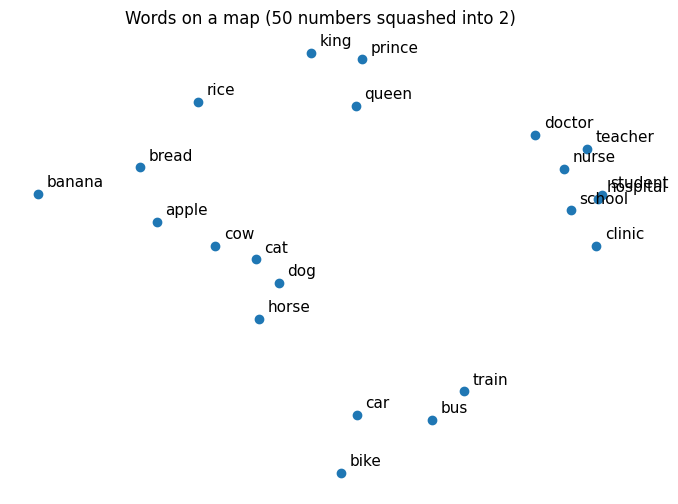

In [7]:
plot_words(["dog", "cat", "horse", "cow", "car", "bus", "train", "bike",
            "doctor", "nurse", "hospital", "clinic", "school", "teacher", "student",
            "king", "queen", "prince", "bread", "rice", "apple", "banana"])

Your answer: There are clear groups: animals (cow, cat, dog, horse), food (bread, apple, rice, banana), transport (car, bus, train, bike), royalty (king, queen, prince) and one group with care and education together (doctor, nurse, hospital, clinic, teacher, student, school). `banana` is the odd one out, it sits far to the left, away from the other food words.

### 1.6 Arithmetic with meaning

Because words are numbers, you can calculate with them.
`analogy("man", "king", "woman")` answers: *man is to king as woman is to ...?*

Run the first two. Then **predict** what `analogy("man", "doctor", "woman")`
will answer, and run it.

In [8]:
print(analogy("man", "king", "woman"))
print(analogy("paris", "france", "berlin"))

['queen', 'throne', 'prince', 'daughter', 'elizabeth']
['germany', 'denmark', 'poland', 'austria', 'german']


Your prediction: I think the answer will be `nurse`.

In [9]:
print(analogy("man", "doctor", "woman"))
print(analogy("man", "manager", "woman"))

['nurse', 'child', 'pregnant', 'mother', 'patient']
['assistant', 'owner', 'employee', 'hired', 'executive']


Your answer: My prediction was right: the first answer is `nurse`, followed by child, pregnant, mother and patient. For `manager` the answer is `assistant`. The embedding learned from its texts that a man is a doctor or a manager and a woman is a nurse or an assistant. That is a stereotype, not a fact.

### 1.7 One word, one list of numbers

Run the cell below. `bank` has **one** list of numbers, so it has one set of
neighbours.

In [10]:
print(neighbours("bank"))

[('banks', 0.87), ('securities', 0.8), ('banking', 0.8), ('investment', 0.78), ('exchange', 0.78), ('financial', 0.77), ('credit', 0.76), ('lender', 0.75)]


Your answer: All neighbours of `bank` are about money: banks, securities, banking, investment, credit, lender. The river bank is missing completely. One word has one list of numbers, so the embedding can only keep one meaning.

---

**LEARNING WAVE 2 · SLIDES 9-14**

## 2. Order and memory: RNN and LSTM

Sections 2.1 to 2.7. Word counts throw away the order of the words. A recurrent network reads the words one by one and carries a memory along. How long can it keep that memory?

### 2.1 Order matters

Bag of words and plain embeddings treat a text as a pile of words. Run the
cell below: it compares the word counts of two sentences with opposite
meanings.

In [11]:
from collections import Counter

good = "the food was good not bad at all"
bad = "the food was bad not good at all"

print(Counter(good.split()))
print(Counter(bad.split()))
print("Same counts?", Counter(good.split()) == Counter(bad.split()))

Counter({'the': 1, 'food': 1, 'was': 1, 'good': 1, 'not': 1, 'bad': 1, 'at': 1, 'all': 1})
Counter({'the': 1, 'food': 1, 'was': 1, 'bad': 1, 'not': 1, 'good': 1, 'at': 1, 'all': 1})
Same counts? True


Your answer: Both sentences have exactly the same word counts (Same counts? True), but they mean the opposite. A model that only counts words cannot tell them apart, so the order of the words is needed.

### 2.2 Telephone game (in class, 6 minutes, no laptop)

Your teacher will explain the rules. You play two rounds:

1. **The plain chain (the RNN).** A message is whispered down the line. Everyone only knows what the person before them whispered.
2. **The note-taking chain (the LSTM).** Everyone gets a small notebook and may write down one important thing from the message, keep it, and pass it on next to the whisper.

Write down what you notice: what got lost in round 1, and what did the
notebook change in round 2?

Your answer: I was not in class for this activity. What the game is meant to show, from the notebook: in the plain chain (the RNN) everyone only knows the last whisper, so the beginning of the message gets lost along the way. In the note-taking chain (the LSTM) one important thing can be written down, kept and passed on, so it survives until the end.

### 2.3 The memory test

A tiny game to measure memory. Every **sequence** starts with a secret
colour word (red, green, blue or yellow), followed by a number of filler
words. The model reads the whole sequence, word by word, and then has to say
**which colour the sequence started with**.

The only way to win is to remember the first word until the end.

The cell below prepares two tiny models: an **RNN** and an **LSTM**. It also
contains the function `memory_test(kind, length)`, which trains a model for
a few seconds and returns its score on new sequences (1.0 = always right,
0.25 = just guessing). Run it, then look at two examples.

In [12]:
# Run, do not read: two tiny models and a game to test their memory
import torch
import torch.nn as nn

colours = ["red", "green", "blue", "yellow"]
fillers = ["the", "cat", "sat", "on", "a", "mat", "and", "looked", "at", "dog"]

def make_data(n, length, generator):
    first = torch.randint(0, 4, (n,), generator=generator)
    filler = torch.randint(4, 14, (n, length), generator=generator)
    return torch.cat([first.unsqueeze(1), filler], dim=1), first

class TinyReader(nn.Module):
    def __init__(self, kind):
        super().__init__()
        self.embedding = nn.Embedding(14, 16)
        if kind == "rnn":
            self.reader = nn.RNN(16, 32, batch_first=True)
        else:
            self.reader = nn.LSTM(16, 32, batch_first=True)
            for name, p in self.reader.named_parameters():
                if "bias" in name:
                    p.data[32:64] = 1.0     # start with 'keep what you remember'
        self.answer = nn.Linear(32, 4)

    def forward(self, x):
        out, _ = self.reader(self.embedding(x))
        return self.answer(out[:, -1, :])    # the answer comes after the LAST word

def memory_test(kind, length, seed=1):
    torch.manual_seed(seed)
    g = torch.Generator().manual_seed(seed)
    x_train, y_train = make_data(2000, length, g)
    x_test, y_test = make_data(1000, length, g)
    net = TinyReader(kind)
    optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
    loss_function = nn.CrossEntropyLoss()
    for epoch in range(30):
        order = torch.randperm(2000)
        for i in range(0, 2000, 100):
            batch = order[i:i + 100]
            optimizer.zero_grad()
            loss_function(net(x_train[batch]), y_train[batch]).backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
    with torch.no_grad():
        return round((net(x_test).argmax(1) == y_test).float().mean().item(), 2)

def show_example(length):
    g = torch.Generator().manual_seed(length)
    x, y = make_data(1, length, g)
    tokens = x[0].tolist()
    print(colours[tokens[0]], " ".join(fillers[t - 4] for t in tokens[1:]))
    print("-> the model must answer:", colours[int(y[0])])
    print()

In [13]:
show_example(5)
show_example(15)

yellow a looked mat and the
-> the model must answer: yellow

red dog the on looked a a cat dog dog on the looked on dog mat
-> the model must answer: red



**Predict first.** We test sequences with 5, 10, 20 and 30 filler words
after the colour. For each length, will the model still remember the
colour? Write your guess for the RNN and for the LSTM.

Your prediction: RNN: it remembers the colour after 5 filler words, but from 10 filler words it starts to forget. LSTM: it remembers the colour at every length (5, 10, 20 and 30).

### 2.4 Test the RNN

This trains a fresh RNN for each length (about 5 seconds each) and prints
the score.

In [14]:
lengths = [5, 10, 20, 30]
rnn_scores = []
for length in lengths:
    score = memory_test("rnn", length)
    rnn_scores.append(score)
    print("RNN, after", length, "filler words ->", score)

RNN, after 5 filler words -> 1.0


RNN, after 10 filler words -> 1.0


RNN, after 20 filler words -> 0.47


RNN, after 30 filler words -> 0.23


### 2.5 Test the LSTM

Exactly the same game, with the LSTM instead.

In [15]:
lstm_scores = []
for length in lengths:
    score = memory_test("lstm", length)
    lstm_scores.append(score)
    print("LSTM, after", length, "filler words ->", score)

LSTM, after 5 filler words -> 1.0


LSTM, after 10 filler words -> 1.0


LSTM, after 20 filler words -> 1.0


LSTM, after 30 filler words -> 1.0


### 2.6 Compare

Run the cell below to draw both results in one picture, then answer.

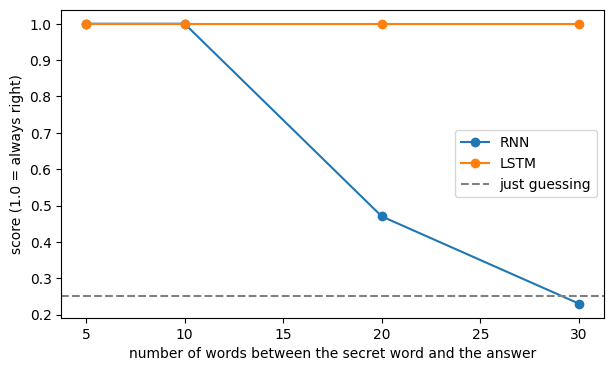

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(lengths, rnn_scores, marker="o", label="RNN")
plt.plot(lengths, lstm_scores, marker="o", label="LSTM")
plt.axhline(0.25, color="grey", linestyle="--", label="just guessing")
plt.xlabel("number of words between the secret word and the answer")
plt.ylabel("score (1.0 = always right)")
plt.legend()
plt.show()

Your answer: The RNN remembers the first word after 5 and 10 filler words (score 1.0), drops to 0.47 after 20 and to 0.23 after 30, which is the same as guessing. The LSTM scores 1.0 at every length. My prediction was partly right: the LSTM remembers, but the RNN held on longer than I thought, it starts to forget at 20, not at 10.

### 2.7 Your turn: push the LSTM

Test the LSTM on a much longer sequence, for example 50 filler words. Use
`memory_test("lstm", 50)` and print the result. Do it a second time with
`seed=2` as an extra argument (`memory_test("lstm", 50, seed=2)`).

In [17]:
print(memory_test("lstm", 50))
print(memory_test("lstm", 50, seed=2))

0.73


0.74


Your answer: With 50 filler words the LSTM scores 0.73, and 0.74 with seed=2. That is still much better than guessing (0.25), but it is no longer perfect. So the LSTM remembers longer than the RNN, but long texts are still hard for it.

---

**LEARNING WAVE 3 · SLIDES 15-20**

## 3. Context and attention: transformers

Sections 3.1 to 3.7. A transformer does not read one word at a time: every word looks at every other word at once. We use two small pre-trained transformers.

### 3.0 Load the transformers

Run this cell once. It downloads two small pre-trained models:
**DistilBERT**, which has been taught to read English (and, in a second
version, to judge whether a text is positive or negative), and **DistilGPT-2**, which has been taught to predict the next
word. This takes up to a minute. Ignore warnings about tokens.

In [18]:
# Run, do not read: loads two small pre-trained transformers
from transformers import pipeline, AutoModel, AutoModelForCausalLM, AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
sentiment = pipeline("sentiment-analysis", model=checkpoint)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
encoder = AutoModel.from_pretrained("distilbert-base-uncased").eval()

lm_tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
lm = AutoModelForCausalLM.from_pretrained("distilgpt2").eval()

def show(sentences):
    for result, sentence in zip(sentiment(sentences), sentences):
        print(result["label"], round(result["score"], 2), "|", sentence)

def word_vector(sentence, word):
    # the list of numbers for ONE word, as this model sees it IN THIS sentence
    enc = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        hidden = encoder(**enc).last_hidden_state[0]
    position = enc["input_ids"][0].tolist().index(tokenizer.convert_tokens_to_ids(word))
    v = hidden[position]
    return v / v.norm()

def context_similarity(sentence_1, sentence_2, word="bank"):
    return round(float(word_vector(sentence_1, word) @ word_vector(sentence_2, word)), 2)

def next_words(prompt, n=6):
    ids = lm_tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        logits = lm(**ids).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)
    top = torch.topk(probs, n)
    for p, i in zip(top.values, top.indices):
        print(round(float(p), 3), "|", lm_tokenizer.decode(int(i)))

def write(prompt, temperature=1.0, length=25, seed=1):
    torch.manual_seed(seed)
    ids = lm_tokenizer(prompt, return_tensors="pt")
    out = lm.generate(**ids, max_new_tokens=length, do_sample=True,
                      temperature=temperature, pad_token_id=lm_tokenizer.eos_token_id)
    print(lm_tokenizer.decode(out[0]).replace("\n", " "))

def pronoun_odds(prompt):
    ids = lm_tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        probs = torch.softmax(lm(**ids).logits[0, -1], dim=-1)
    she = float(probs[lm_tokenizer.encode(" she")[0]])
    he = float(probs[lm_tokenizer.encode(" he")[0]])
    print(prompt, "| she:", round(she, 3), "| he:", round(he, 3))

### 3.1 One word, many meanings

In 1.7 `bank` had one list of numbers, always. A transformer gives a word a
**different list of numbers in every sentence**, because it looks at the
other words first.

`context_similarity(sentence_1, sentence_2)` compares the lists of numbers
of the word `bank` in two sentences. **Predict first:** which comparison
will be the *highest* and which the *lowest*?

- A: `she sat on the bank of the river`
- B: `he deposited money at the bank`
- C: `the bank approved the loan`
- D: `we had a picnic on the river bank`

Your prediction: Highest: B and C (both about money). Lowest: the river / money comparisons.

In [19]:
A = "she sat on the bank of the river"
B = "he deposited money at the bank"
C = "the bank approved the loan"
D = "we had a picnic on the river bank"

print("A and D (both river):", context_similarity(A, D))
print("B and C (both money):", context_similarity(B, C))
print("A and B (river / money):", context_similarity(A, B))
print("D and C (river / money):", context_similarity(D, C))

A and D (both river): 0.78
B and C (both money): 0.78
A and B (river / money): 0.56
D and C (river / money): 0.54


Your answer: The two river sentences (0.78) and the two money sentences (0.78) are equally similar, so my prediction that the money pair would be the highest was only half right. The river/money comparisons are clearly lower (0.56 and 0.54), as I expected. The same word `bank` now gets different numbers depending on the sentence, which the embedding in 1.7 could not do.

### 3.2 Be attention (in class, 6 minutes)

Your teacher shows a sentence on screen: *The animal didn't cross the street
because it was too tired.* Every student is one word. The student who is `it`
points at the words they need to look at to know what `it` means, and the
rest of the class checks.

Then the teacher changes the end of the sentence to *... because it was too
wide.* Who does `it` look at now?

Write down: which words did `it` look at, and what changed?

Your answer: I was not in class for this activity. From the notebook: with "too tired", `it` has to look at `animal`, because an animal can be tired. With "too wide", `it` has to look at `street`. Only the last word changed, but the meaning of `it` changed with it. That is what attention does: a word looks at the other words to find out what it means.

### 3.3 Sentiment: where does it fail?

`show([...])` gives you the model's verdict (POSITIVE or NEGATIVE) and how
sure it is (0 to 1) for a list of sentences. Look at the sentences below and
**predict** which ones the model will get wrong.

Your prediction: I think the model will get sentence 3 (double negation), sentence 4 (sarcasm) and sentence 7 (Dutch) wrong.

In [20]:
show(["The clinic helped me a lot.",
      "The clinic did not help me at all.",
      "I wouldn't say the staff were unfriendly.",
      "Great, another two-hour wait. Just what I needed.",
      "The doctor was kind, but the waiting room was awful.",
      "the cluic wuz rly good",
      "Het was een heel goede ervaring."])

POSITIVE 1.0 | The clinic helped me a lot.
NEGATIVE 1.0 | The clinic did not help me at all.
NEGATIVE 0.97 | I wouldn't say the staff were unfriendly.
POSITIVE 0.99 | Great, another two-hour wait. Just what I needed.
NEGATIVE 1.0 | The doctor was kind, but the waiting room was awful.
POSITIVE 1.0 | the cluic wuz rly good
NEGATIVE 0.97 | Het was een heel goede ervaring.


Your answer: My prediction was right. The model got sentence 3 wrong (the double negation, read as negative), sentence 4 (the sarcasm, read as positive with 0.99) and sentence 7 (the Dutch sentence, read as negative although it is positive). The typos in sentence 6 were no problem. Sentence 5 has a good and a bad part and the model chose negative. The model is very sure every time, also when it is wrong.

Now try **three sentences of your own** that you think will fool the
model. Use `show(["sentence one", "sentence two", "sentence three"])`.

In [21]:
show(["The doctor was not unfriendly at all.",
      "Thanks a lot for losing my test results, really made my week.",
      "the doc was gr8, sorted me out rly quick"])

POSITIVE 0.93 | The doctor was not unfriendly at all.
POSITIVE 1.0 | Thanks a lot for losing my test results, really made my week.
NEGATIVE 0.99 | the doc was gr8, sorted me out rly quick


Your answer: Two of my three sentences fooled the model. The sarcastic sentence about the lost test results was read as positive (1.0), and the positive sentence with slang ("gr8", "rly") was read as negative (0.99). "The doctor was not unfriendly at all" did not fool it, the model said positive (0.93).

### 3.4 What an LLM does: guess the next word

ChatGPT, Claude and Gemini are transformers trained to do one thing:
**predict the next word**. `next_words(prompt)` shows the six most likely
next words (with their probability) according to DistilGPT-2, a small
relative. Run it, then try your own prompt.

In [22]:
next_words("The doctor said that")

0.174 |  he
0.159 |  the
0.044 |  she
0.042 |  it
0.036 |  his
0.026 |  if


In [23]:
next_words("The patient said that")

0.227 |  he
0.177 |  she
0.107 |  the
0.06 |  they
0.032 |  it
0.031 |  her


Your answer: After "The doctor said that" the most likely next words are he (0.174), the (0.159) and she (0.044). For my own prompt "The patient said that" I get he (0.227), she (0.177) and the (0.107). The model does not know anything about a real doctor or patient, it only gives the words that most often came next in the texts it learned from. For the doctor "he" is about four times more likely than "she", for the patient they are much closer.

### 3.5 Temperature

`write(prompt, temperature=...)` lets the model keep adding words. The
**temperature** sets how adventurous it is: low = always take the most likely
next word, high = sometimes pick an unlikely one. Run both and compare.

In [24]:
write("The doctor said that", temperature=0.3)
print()
write("The doctor said that", temperature=1.5)

The doctor said that the patient was not in the hospital for the first time in the past two weeks.        



The doctor said that after receiving 10 days of intensive treatment for multiple sclerosis, I was about to fall behind the rate in my primary care system but


Your answer: With temperature 0.3 the text is a normal, safe sentence about a patient in the hospital. With temperature 1.5 the text is longer and more surprising, but it also loses the thread and makes less sense.

### 3.6 What did it learn from the internet?

A language model learned from texts written by people. The cell below asks
the model how likely the next word is **she** or **he** after four different
jobs.

In [25]:
pronoun_odds("The nurse said that")
pronoun_odds("The engineer said that")
pronoun_odds("The doctor said that")
pronoun_odds("The teacher said that")

The nurse said that | she: 0.224 | he: 0.032
The engineer said that | she: 0.011 | he: 0.109


The doctor said that | she: 0.044 | he: 0.174
The teacher said that | she: 0.162 | he: 0.147


Your answer: After `nurse` the model expects she (0.224) much more than he (0.032). After `engineer` (0.011 against 0.109) and `doctor` (0.044 against 0.174) it expects he. Only `teacher` is almost equal (0.162 against 0.147). The model copied these stereotypes from the texts on the internet it learned from.

### 3.7 Who is misread?

You saw three kinds of failure today: a stereotype in the embedding (1.6),
a sarcastic sentence (3.3) and a Dutch sentence (3.3). Imagine a clinic's
helpline that uses a language model to sort incoming messages into *urgent*
and *not urgent*.

Which people would be misread most often, and what would a responsible
clinic do about it?

Your answer: People who do not write standard English would be misread most often: people who write in another language (the Dutch sentence was read as negative), and people who are sarcastic or say things in an indirect way. On a helpline that means an urgent message can be sorted as not urgent. A responsible clinic would not let the model decide alone: a human reads the messages the model sorts as not urgent, messages in other languages go straight to a person, and the model is tested on real messages from its own patients before it is used.

---

## 4. Big individual assignment: stress-test a language model

**You are a tester, not a builder.** An organisation wants to use the
sentiment model from section 3 to read feedback from its users. Before it
does, it asks you: **where does this model fail, and who would that hurt?**

Pick a context you care about (a clinic, a food bank, a housing association,
a school, a municipality ...). You work with the pre-trained model `sentiment`
and the `show` function from section 3.

**Required skills and outputs**

1. **A test set of at least 12 sentences** about your context, covering at
   least four of these kinds: negation, mixed feelings, sarcasm or irony,
   a long sentence where the key word is far from the end, typos or slang,
   a sentence in another language (for example Dutch).
2. **Your own label first.** Before running anything, write down for each
   sentence what a person would say (positive or negative).
3. **Run the model** and collect the results in a table (a pandas
   DataFrame): sentence, your label, the model's label, its confidence, and
   whether they agree.
4. **Error analysis.** Which kinds of sentences fail? For three failures, say
   what a reader would have needed to get it right (the order of the words,
   a memory of an earlier word, the context around a word) and which step of
   today's ladder (embedding, RNN, LSTM, transformer) would or would not
   have handled it, and why.
5. **A bias probe.** Use `next_words` or `pronoun_odds` with at least two
   prompts that differ in one word (for example two jobs, two names or two
   nationalities) and describe what changes.
6. **A written judgement** (about 150 words): would you let this model read
   the users' feedback? Under which conditions? Who is misread, and what
   does the organisation do about them?

**Bonus options**

- Run your test set through a second model from <https://huggingface.co/models>
  (search for a multilingual sentiment model) by creating a second
  `pipeline("sentiment-analysis", model="...")`, and compare the table.
- Try three different temperatures with `write` for one story prompt and
  describe how the text changes.
- Find a biased analogy in the embeddings of section 1 with `analogy`.

You are graded on the honesty of your error analysis and on your reasoning
about harm, not on how many sentences the model gets right.

**1. Context I chose**

A health clinic (GP practice) that wants to use the sentiment model to read written feedback from its patients.

In [26]:
# 2. My test sentences and my own labels (written BEFORE running the model)
import pandas as pd

tests = [
    ("I can't say I was unhappy with the treatment.", "negation", "POSITIVE"),
    ("The waiting time was not short.", "negation", "NEGATIVE"),
    ("Great doctor, terrible reception.", "mixed feelings", "POSITIVE"),
    ("Oh great, another three weeks of waiting for a five-minute appointment.", "sarcasm", "NEGATIVE"),
    ("Wonderful, the phone line was busy all morning again.", "sarcasm", "NEGATIVE"),
    ("I was disappointed, although the receptionist smiled, the waiting room was clean, the coffee was free and the parking was easy to find.", "long sentence", "NEGATIVE"),
    ("It was excellent, even though I arrived late, forgot my insurance card, had to fill in three forms and the printer was broken.", "long sentence", "POSITIVE"),
    ("waitin room was a joke, staff dont care tbh", "typos / slang", "NEGATIVE"),
    ("Teh nurse was verry kind and helpfull.", "typos / slang", "POSITIVE"),
    ("Lekarz był bardzo miły i wszystko mi wytłumaczył.", "Polish", "POSITIVE"),
    ("Czekałam dwie godziny i nikt mnie nie przeprosił.", "Polish", "NEGATIVE"),
    ("Nie polecam tej przychodni.", "Polish", "NEGATIVE"),
    ("Pani w rejestracji była niemiła, ale lekarz świetny.", "Polish", "POSITIVE"),
]
df = pd.DataFrame(tests, columns=["sentence", "kind", "my_label"])

In [27]:
# 3. Run the model, build the table (pandas DataFrame)
results = sentiment(df["sentence"].tolist())
df["model_label"] = [r["label"] for r in results]
df["confidence"] = [round(r["score"], 2) for r in results]
df["agree"] = df["my_label"] == df["model_label"]

pd.set_option("display.max_colwidth", None)
print("The model agrees with me on", df["agree"].sum(), "of", len(df), "sentences")
df

The model agrees with me on 6 of 13 sentences


,sentence,kind,my_label,model_label,confidence,agree
0,I can't say I was unhappy with the treatment.,negation,POSITIVE,NEGATIVE,0.97,False
1,The waiting time was not short.,negation,NEGATIVE,POSITIVE,1.00,False
2,"Great doctor, terrible reception.",mixed feelings,POSITIVE,NEGATIVE,0.98,False
3,"Oh great, another three weeks of waiting for a five-minute appointment.",sarcasm,NEGATIVE,NEGATIVE,0.99,True
4,"Wonderful, the phone line was busy all morning again.",sarcasm,NEGATIVE,POSITIVE,1.00,False
5,"I was disappointed, although the receptionist smiled, the waiting room was clean, the coffee was free and the parking was easy to find.",long sentence,NEGATIVE,NEGATIVE,1.00,True
6,"It was excellent, even though I arrived late, forgot my insurance card, had to fill in three forms and the printer was broken.",long sentence,POSITIVE,NEGATIVE,1.00,False
7,"waitin room was a joke, staff dont care tbh",typos / slang,NEGATIVE,NEGATIVE,1.00,True
8,Teh nurse was verry kind and helpfull.,typos / slang,POSITIVE,POSITIVE,0.99,True
9,Lekarz był bardzo miły i wszystko mi wytłumaczył.,Polish,POSITIVE,NEGATIVE,0.98,False


In [28]:
# 4. Which sentences failed? Agreement per kind of sentence
df.groupby("kind")["agree"].agg(["sum", "count"])

,sum,count
kind,,
Polish,2,4
long sentence,1,2
mixed feelings,0,1
negation,0,2
sarcasm,1,2
typos / slang,2,2


**4. Error analysis**

The model agreed with me on 6 of 13 sentences. By kind: negation 0 of 2, mixed feelings 0 of 1, sarcasm 1 of 2, long sentences 1 of 2, typos/slang 2 of 2, Polish 2 of 4. The model labelled all four Polish sentences NEGATIVE, so the two Polish "agreements" look like luck, not understanding. Typos and slang were not a problem.

**Failure 1 - "I can't say I was unhappy with the treatment." (me: positive, model: negative, 0.97).** A reader needs the order of the words: "can't say" comes before "unhappy" and turns it around. A word embedding has no order, it only sees "unhappy". An RNN or LSTM reads in order and could in principle catch it. A transformer can connect "can't" and "unhappy", but this one still failed.

**Failure 2 - "It was excellent, even though I arrived late, forgot my insurance card, had to fill in three forms and the printer was broken." (me: positive, model: negative, 1.00).** A reader needs a memory of an earlier word: the opinion is "excellent" at the very start, and the rest is a list of problems that are not about the clinic's care. An RNN would forget the beginning of such a long sentence. An LSTM is built to keep it. A transformer sees all words at once, so it did not forget "excellent", but the many negative words at the end outweighed it.

**Failure 3 - "The waiting time was not short." (me: negative, model: positive, 1.00).** A reader needs the context around a word: "short" is only good because it is about waiting time, so "not short" is a complaint. An embedding gives "short" one fixed meaning. A transformer is the step that should handle this, because the meaning of a word depends on the words around it, but it still got it wrong.

In all three cases the transformer has the right mechanism and still fails. The model was trained on English movie reviews, not on patient feedback, so the problem is the data it learned from.

In [29]:
# 5. Bias probe (two prompts that differ in one word)
pronoun_odds("The receptionist said that")
pronoun_odds("The surgeon said that")

The receptionist said that | she: 0.098 | he: 0.11
The surgeon said that | she: 0.024 | he: 0.143


**5. Bias probe**

I compared two prompts that differ in one word: "The receptionist said that" and "The surgeon said that". After "receptionist" the model gives "she" 0.098 and "he" 0.110, almost equal. After "surgeon" it gives "she" 0.024 and "he" 0.143, so "he" is about six times more likely. Only the job changed. The model learned from texts on the internet that a surgeon is a man.

**6. Written judgement**

Would I let this model read the patients' feedback? Only under conditions. On my 13 test sentences the model agreed with me 6 times, and it was 94 to 100% confident even when it was wrong, so the confidence score cannot be used as a warning sign.

Two groups are misread. First, patients who do not write in English: all four Polish sentences were labelled negative, including a compliment for the doctor. Second, patients who complain politely or with sarcasm: the complaints about the waiting time and the busy phone line were read as positive, so nobody would see them.

My conditions: (1) feedback that is not in English goes to a human reader or to a multilingual model; (2) the model is only used for overall statistics, never for a decision about one patient; (3) before using it, the clinic tests it on its own real feedback.

---

## 5. Wrap-up

### 5.1 The ladder

Each step fixed a weakness of the one before:

| Model | What it does well | What it still cannot do |
|-------|-------------------|-------------------------|
| Bag of words | counts which words occur, simple and fast | no order, no meaning |
| **Word embeddings** | words that are used alike get similar numbers | one fixed meaning per word, no order |
| **RNN** | reads in order, any length | forgets the beginning of long texts |
| **LSTM** | keeps what matters in a memory lane | reads one word at a time, slow, long texts still hard |
| **Transformer** | every word looks at every other word at once, meaning depends on the context | needs huge data and computers; copies the bias of its data |

### 5.2 Five things to remember

1. A computer does not read. It turns text into numbers and calculates.
2. Embeddings give every word a place on a map of meaning, so similar words end up close.
3. Order matters. An RNN reads in order but forgets; an LSTM remembers longer.
4. A transformer lets every word look at every other word. That is why context finally works, and it is the foundation of ChatGPT, Claude and Gemini.
5. All of these models copy the data they learned from. They sound sure even when they are wrong, so keep a human in the loop and ask who is misread.

### 5.3 Homework (while you work on the hackathon)

Complete these DataCamp chapters:

1. *Recurrent Neural Networks (RNN) for Language Modeling with Keras*: **Chapter 1** and **Chapter 4**
   <https://app.datacamp.com/learn/courses/recurrent-neural-networks-rnn-for-language-modeling-with-keras>
2. *Introduction to LLMs in Python*: the whole chapter **Getting started with Large Language Models (LLMs)**
   <https://campus.datacamp.com/courses/introduction-to-llms-in-python/getting-started-with-large-language-models-llms>

Also finish section 4 and upload the notebook to `Term 1/Week 6/homework/` in your portfolio.

**Next week:** Computer Vision
**Friday:** the hackathon. You find out on the day which tool you use and which problem you solve.